# CSAF Figures

## Dataset loading

In [23]:
import pandas as pd
import numpy as np
import pygmt

from pyproj import Proj, Geod
P = Proj('epsg:32610')
G = Geod(ellps='WGS84')

In [27]:
# Open results

#points = pd.read_csv(
#    f'/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/ErfProfileResults_ProfLen{profile_length}_SwathWidth{swath_width}_10mSpacing_Calaveras.csv'
#)
saf200 = pd.read_csv(
    f'/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/ErfProfileResults_ProfLen{200}_SwathWidth{10}_10mSpacing_SAF_1000mRollingMedian.csv'
)
saf500 = pd.read_csv(
    f'/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/ErfProfileResults_ProfLen{500}_SwathWidth{10}_10mSpacing_SAF_1000mRollingMedian.csv'
)
saf1500 = pd.read_csv(
    f'/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/MicmacAreaResults/SsResolOpt1/MaskedResults/ErfProfileResults_ProfLen{1500}_SwathWidth{10}_10mSpacing_SAF_1000mRollingMedian.csv'
)


In [15]:
icpdf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/FromChelsea/Creep_rates_plot/Creep_results_Scott_et_al_withHeader.txt',sep='\s+')

bhdf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/GIS/FinalFaultGeomFiles/BufordandHarsh.txt')
# Change datum from BH likely NAD27 to WGS84
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4267", "EPSG:4326", always_xy=True)
P = Proj('epsg:32610')
G = Geod(ellps='WGS84')
bhdf['Lon84'],bhdf['Lat84'] = transformer.transform(bhdf['Lon'],bhdf['Lat'])
bhdf['easting'] = P(bhdf['Lon84'].values,bhdf['Lat84'].values)[0]
bhdf['northing'] = P(bhdf['Lon84'].values,bhdf['Lat84'].values)[1]
bhdf["dist_from_parkfield_m"] = np.sqrt(
    (bhdf.easting - Px)**2 +
    (bhdf.northing - Py)**2
)

gnss = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/cwu.final_nam14.vel',skiprows=35,sep='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_39270/1682079436.py:1: SyntaxWarning: invalid escape sequence '\s'
  icpdf = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/FromChelsea/Creep_rates_plot/Creep_results_Scott_et_al_withHeader.txt',sep='\s+')
/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_39270/1682079436.py:17: SyntaxWarning: invalid escape sequence '\s'
  gnss = pd.read_csv('/Volumes/ProjectsGarlockCSAF/CSAF_Lidar/OtherDisplacements/cwu.final_nam14.vel',skiprows=35,sep='\s+')


## Overview map

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
from shapely import wkt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import math
import pygmt 

In [5]:
# Bounding box
overview_region = [-122.0,-120.1,35.8,37.15]

grid = pygmt.datasets.load_earth_relief(
    resolution='15s',
    region=overview_region,
    use_srtm=True)

dgrid = pygmt.grdgradient(grid=grid, radiance=[270, 40])


In [6]:
gnss.columns

Index(['*Dot#', 'Name', 'Ref_epoch', 'Ref_jday', 'Ref_X', 'Ref_Y', 'Ref_Z',
       'Ref_Nlat', 'Ref_Elong', 'Ref_Up...', 'dX/dt', 'dY/dt', 'dZ/dt', 'SXd',
       'SYd', 'SZd', 'Rxy', 'Rxz', 'Rzy', 'dN/dt', 'dE/dt', 'dU/dt', 'SNd',
       'SEd', 'SUd', 'Rne', 'Rnu', 'Reu', 'first_epoch', 'last_epoch'],
      dtype='object')

In [7]:
(gnss[gnss['*Dot#'] == 'PEA1']['dN/dt'].iloc[0] + gnss[gnss['*Dot#'] == 'PEA2']['dN/dt'].iloc[0])/2

np.float64(0.02295)

In [8]:
df = gnss[['Ref_Elong','Ref_Nlat','dE/dt','dN/dt']]
df['Ref_Elong'] = df['Ref_Elong'] - 360
df.columns = ['x','y','east_velocity','north_velocity']
# remove mean between pea1 and 2
refN = (gnss[gnss['*Dot#'] == 'PEA1']['dN/dt'].iloc[0] + gnss[gnss['*Dot#'] == 'PEA2']['dN/dt'].iloc[0])/2
refE = (gnss[gnss['*Dot#'] == 'PEA1']['dE/dt'].iloc[0] + gnss[gnss['*Dot#'] == 'PEA2']['dE/dt'].iloc[0])/2
df['east_velocity'] = df['east_velocity'] - refE
df['north_velocity'] = df['north_velocity'] - refN
df['east_sigma'] = np.zeros(len(df))
df['north_sigma'] = np.zeros(len(df))
df['correlation_EN'] = np.zeros(len(df))

/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_77757/3381411718.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ref_Elong'] = df['Ref_Elong'] - 360
/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_77757/3381411718.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['east_velocity'] = df['east_velocity'] - refE
/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_77757/3381411718.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [ ]:
{'x':, 'y':, 'east_velocity':, 'north_velocity':, 'east_sigma':,
       'north_sigma':, 'correlation_EN':}

Index(['x', 'y', 'east_velocity', 'north_velocity', 'east_sigma',
       'north_sigma', 'correlation_EN'],
      dtype='object')

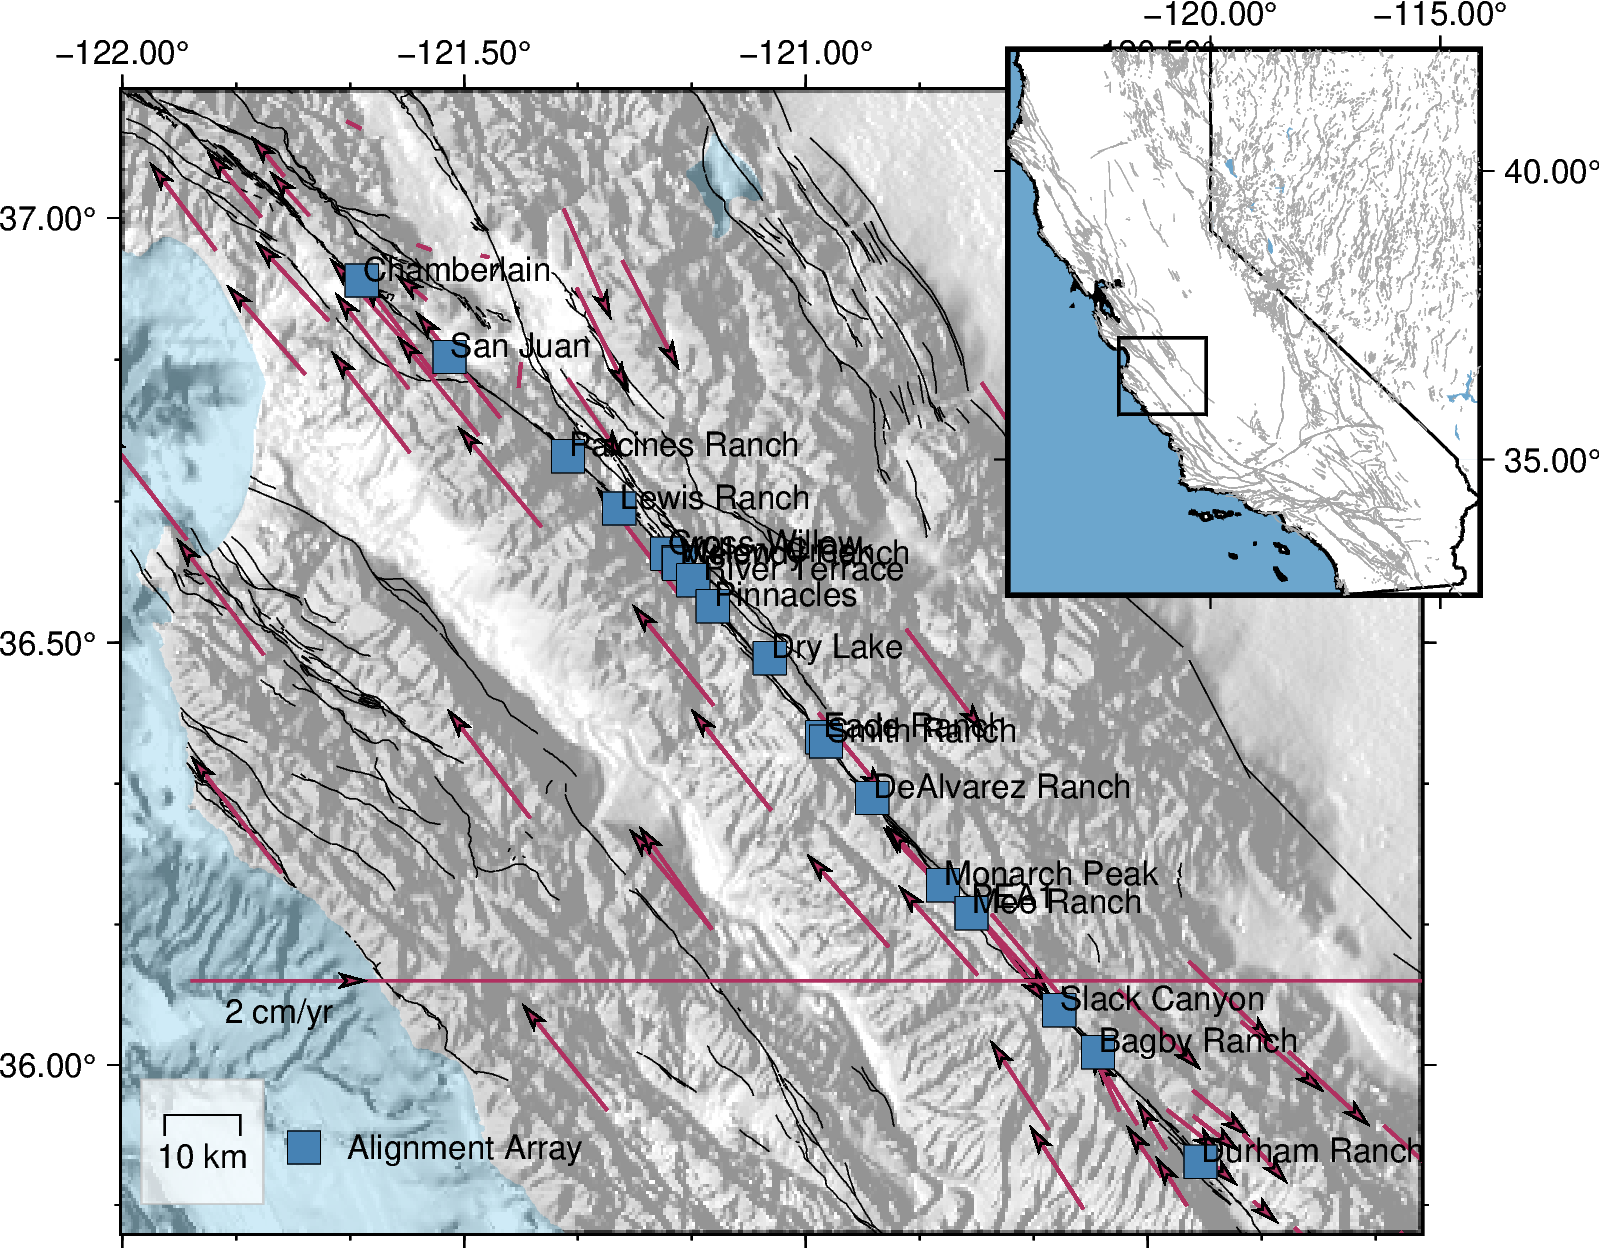

In [ ]:
# Include overview with lidar 
# qfaults
# aa locations, gps locations

# --- Plot with PyGMT ---
fig = pygmt.Figure()

# Configuration for the 'current figure'.
pygmt.config(MAP_FRAME_TYPE="plain")
pygmt.config(FORMAT_GEO_MAP="ddd.xx")
pygmt.config(FONT_ANNOT="8p,Helvetica,black")

fig.basemap(region=overview_region, projection="M11c", frame=["WNse", "af"])
fig.coast(water="skyblue")

# Hillshade
pygmt.makecpt(cmap="gray", series=[-1.5, 0.3, 0.01])
fig.grdimage(grid=dgrid,cmap=True,transparency=40)

fig.plot('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp')

fig.velo(data=df,spec="e75/0.95",pen="0.8p,maroon",line=True,vector="0.25c+p1p+e+gmaroon")
fig.text(x=gnss[gnss['*Dot#'] == 'PEA1'].Ref_Elong.iloc[0],y=gnss[gnss['*Dot#'] == 'PEA1'].Ref_Nlat.iloc[0],
         text='PEA1',justify='BL',clearance='0.2c/0.2c')
fig.velo(data={'x':-121.9, 
               'y':36.1, 
               'east_velocity':0.02, 
               'north_velocity':0, 
               'east_sigma':0,
               'north_sigma':0, 
               'correlation_EN':0},
               spec="e75/0.95",pen="0.8p,maroon",line=True,vector="0.25c+p1p+e+gmaroon")
fig.text(x=-121.85,y=36.05,text='2 cm/yr',justify='BL',clearance='0.2c/0.2c')

fig.plot(x=bhdf.Lon84,y=bhdf.Lat84,style="s0.4c", fill="steelblue",pen="0.1p,black",label='Alignment Array')
fig.text(x=bhdf.Lon,y=bhdf.Lat,text=bhdf.AA,justify='BL',clearance='0.2c/0.2c')

# Scale Bar
fig.basemap(map_scale='JBL+w10k+o-1c/-1c+lkm',box="+c0.1/0.3+gwhite@30+p0.5p,grey@30,solid")
fig.legend(position="jBL+o1.2c/0.3c+l2")

with fig.inset(
    position="jTR+o-1.5c/-1.5c",
    margin='1c',
    region='US.CA',
    projection="M6c",
):
    fig.coast(
        region='US.CA',
        dcw="US.CA+p0.6p,black+gwhite",
        land='white',
        borders='1',
        water='skyblue3',
        frame=["ENsw", "a"],
    )
    rectangle = [[overview_region[0], overview_region[2], overview_region[1], overview_region[3]]]
    fig.plot(data='/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Data/Qfaults_GIS/SHP/Qfaults_US_Database.shp', pen="0.2p,darkgrey")
    fig.plot(data=rectangle,style="r+s", pen="0.7p,black")

fig.savefig('/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/IntroCSAFMap.pdf',dpi=300)

# Export or show
fig.show()

## Distance rate comparison

In [25]:
from matplotlib import rcParams

rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica'],  # Use Helvetica
    'font.size': 8,                    # Global font size
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 8,
    'pdf.fonttype': 42,                # Embed fonts in PDFs for Illustrator
    'ps.fonttype': 42
})

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Function to compute MAD
def mad(x):
    median = np.median(x)
    return np.median(np.abs(x - median))

plt.figure(figsize=(12, 3.5))

# Rolling window in meters
window_m = 1000     # 1 km
half_w = window_m / 2

for pts, color in zip([saf200,saf500,saf1500], ['teal','maroon','indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    npts = len(pts)


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        pts['par_rolling_median'],
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'1 km Rolling Median ({fname})',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        pts['par_rolling_median'] - pts['par_rolling_mad'],
        pts['par_rolling_median'] + pts['par_rolling_mad'],
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )


# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )

# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Velocity (cm/yr)')
plt.title('Central San Andreas Fault Parallel Velocity')

plt.legend(
   #bbox_to_anchor=(1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_39270/2593949501.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])


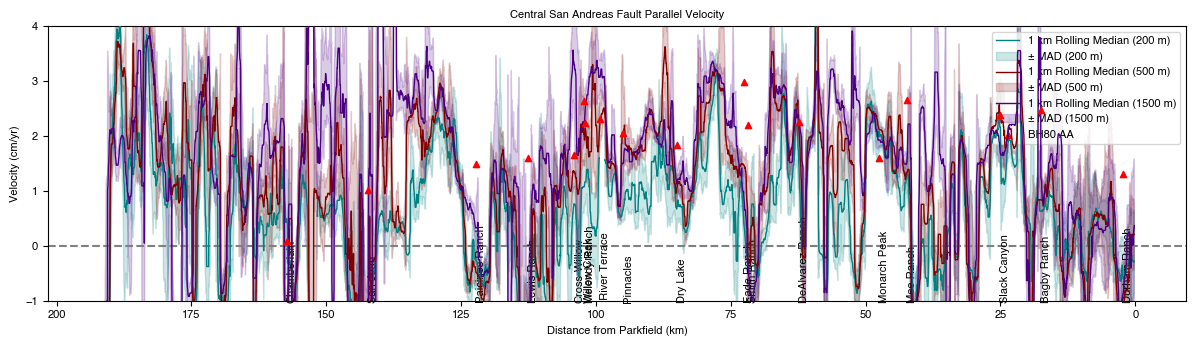

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Function to compute MAD
def mad(x):
    median = np.median(x)
    return np.median(np.abs(x - median))

plt.figure(figsize=(12, 3.5))

# Rolling window in meters
window_m = 1000     # 1 km
half_w = window_m / 2

for pts, color in zip([saf200,saf500,saf1500], ['teal','maroon','indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    npts = len(pts)


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        pts['perp_rolling_median'],
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'1 km Rolling Median ({fname})',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        pts['perp_rolling_median'] - pts['perp_rolling_mad'],
        pts['perp_rolling_median'] + pts['perp_rolling_mad'],
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )


# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='red',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )

# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Velocity (cm/yr)')
plt.title('Central San Andreas Fault Parallel Velocity')

plt.legend(
   #bbox_to_anchor=(1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

## Fault Zone Width

How do widths compare with profile distance?

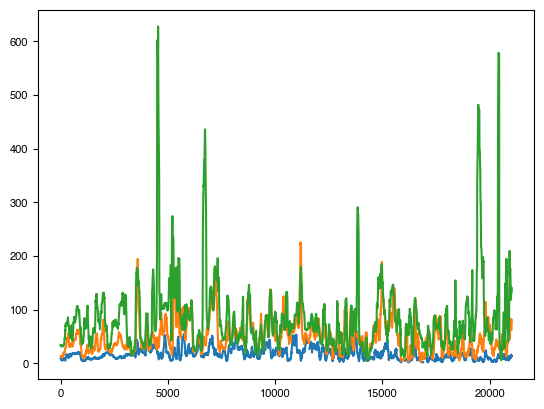

In [30]:
plt.plot(saf200['par_width_rolling_median'])
plt.plot(saf500['par_width_rolling_median'])
plt.plot(saf1500['par_width_rolling_median'])


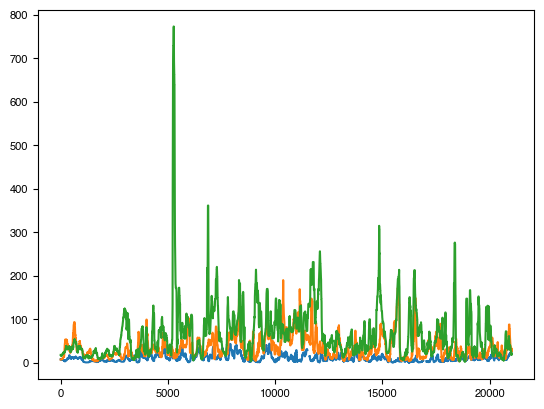

In [70]:
plt.plot(saf200['perp_width_rolling_median'])
plt.plot(saf500['perp_width_rolling_median'])
plt.plot(saf1500['perp_width_rolling_median'])


Slope: 0.3520678750692841
Intercept: 5.146301449029927
R²: 0.21920588937631397
p-value: 0.0
Standard error: 0.004627600070164307


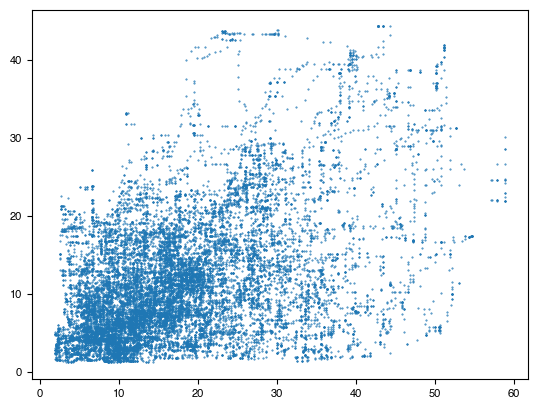

In [75]:
x, y = saf200['par_width_rolling_median'],saf200['perp_width_rolling_median']
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]
plt.scatter(x,y,s=0.2)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value**2)
print("p-value:", p_value)
print("Standard error:", std_err)

Slope: 15.501688429734603
Intercept: 21.07646518204605
R²: 0.21627195910634975
p-value: 0.0
Standard error: 0.21583510670566605


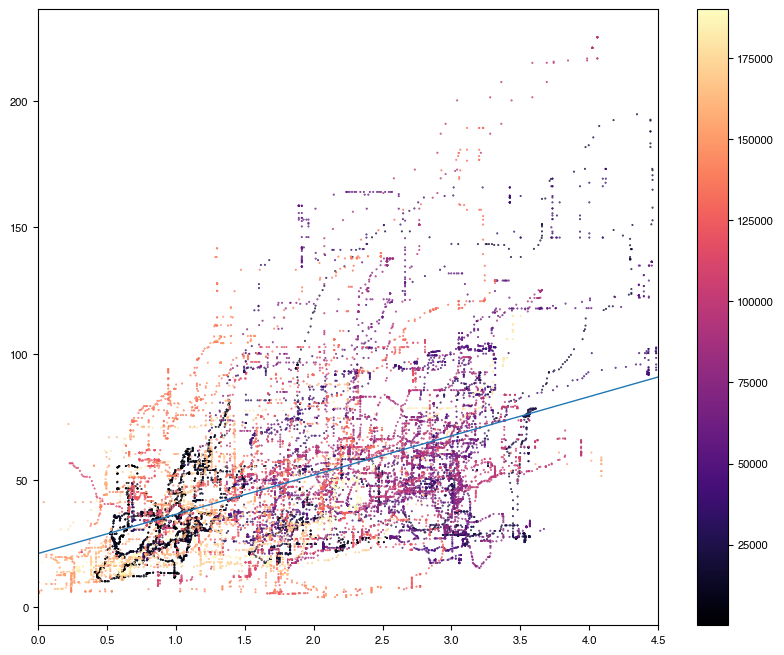

In [67]:
import scipy.stats as stats
import numpy as np


plt.figure(figsize=(10,8))
for pts in [saf500]:#,saf500,saf1500]:
    x = pts["par_rolling_median"].values
    y = pts["par_width_rolling_median"].values
    c = pts['dist_from_parkfield_m'].values

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]
    c = c[mask]

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    print("Slope:", slope)
    print("Intercept:", intercept)
    print("R²:", r_value**2)
    print("p-value:", p_value)
    print("Standard error:", std_err)

    xp = np.linspace(min(x), max(x), 200)
    plt.scatter(x,y,c=c,s=0.2,cmap='magma')
    plt.plot(xp, intercept + slope*xp , linewidth=1)
plt.xlim(0,4.5)
plt.colorbar()
#plt.ylim(0,250)


In [48]:
stats.linregress(x, y)

LinregressResult(slope=np.float64(26.93743488519224), intercept=np.float64(18.151840274396292), rvalue=np.float64(0.44594682272235203), pvalue=np.float64(0.0), stderr=np.float64(0.3993191379751495), intercept_stderr=np.float64(1.0048303537365124))

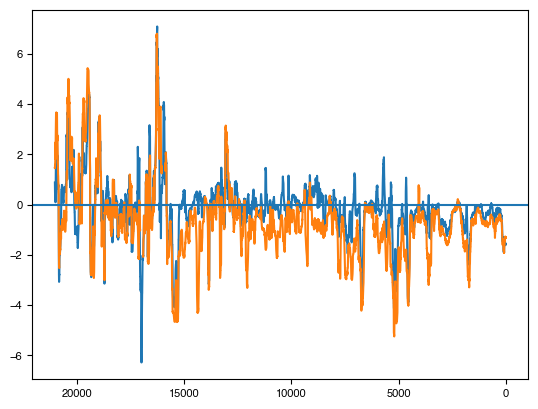

In [68]:
plt.plot(saf500['par_rolling_median']-saf1500['par_rolling_median'])
plt.plot(saf200['par_rolling_median']-saf1500['par_rolling_median'])

plt.axhline(0)
plt.gca().invert_xaxis()  

/var/folders/zn/w54gt7k11csfs1n4z8r3xccsyqhmjz/T/ipykernel_77757/3955993872.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])


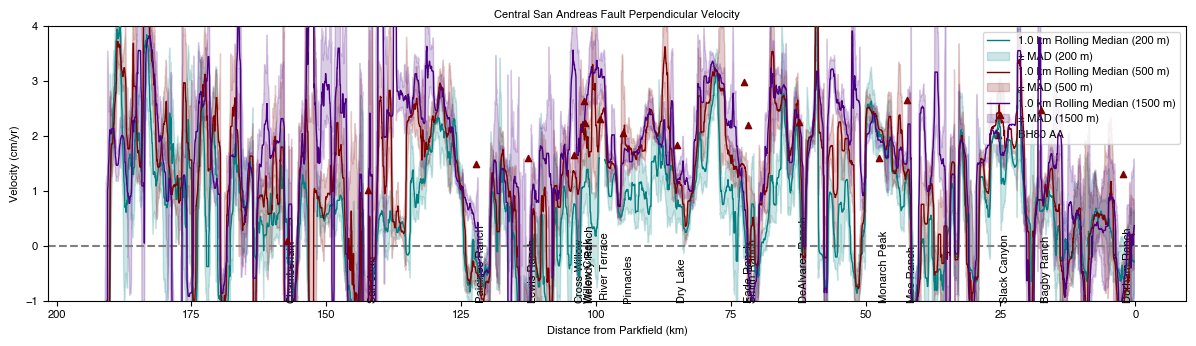

In [62]:
## Perpendicular
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Function to compute MAD
def mad(x):
    median = np.median(x)
    return np.median(np.abs(x - median))

plt.figure(figsize=(12, 3.5))

# Rolling window in meters
window_m = 1000     # 1 km
half_w = window_m / 2

for pts, color in zip([saf200,saf500,saf1500], ['teal','maroon','indigo']):

    if color == 'teal':
        fname = '200 m'
    elif color == 'maroon':
        fname = '500 m'
    else:
        fname = '1500 m'

    # Sort by distance from Parkfield
    pts = pts.sort_values("dist_from_parkfield_m").reset_index(drop=True)

    # Extract arrays
    dist = pts["dist_from_parkfield_m"].values
    vel = (pts["perp_total_offset"] * -1).values  # your sign convention
    npts = len(pts)

    # Prepare arrays for results
    rolling_median = np.full(npts, np.nan)
    rolling_mad = np.full(npts, np.nan)

    # Compute rolling median in a *distance window*
    for i in range(npts):
        # distance window: +/- 500 m
        lo = dist[i] - half_w
        hi = dist[i] + half_w

        mask = (dist >= lo) & (dist <= hi)
        vals = vel[mask]

        if len(vals) > 0:
            rolling_median[i] = np.median(vals)
            rolling_mad[i] = mad(vals)

    # Store in df
    if color == 'teal':
        saf200['perp_rolling_median'] = rolling_median
        saf200['perp_rolling_mad'] = rolling_mad
    elif color == 'maroon':
        saf500['perp_rolling_median'] = rolling_median
        saf500['perp_rolling_mad'] = rolling_mad    
    else:
        saf1500['perp_rolling_median'] = rolling_median
        saf1500['perp_rolling_mad'] = rolling_mad


    # Plot rolling median line (x-axis = distance)
    plt.plot(
        dist,
        rolling_median,
        color=color,
        #s=0.7,
        linewidth=1,
        label=f'{window_m/1000} km Rolling Median ({fname})',
        zorder=7
    )

    ## Plot shaded MAD bounds
    plt.fill_between(
        dist,
        rolling_median - rolling_mad,
        rolling_median + rolling_mad,
        color=color,
        alpha=0.2,
        label=f"± MAD ({fname})"
    )


# Burford & Harsh data
plt.scatter(
    bhdf["dist_from_parkfield_m"],
    bhdf.Rate / 10,
    s=20,
    marker='^',
    color='maroon',
    label='BH80 AA',
    zorder=20
)
for i in range(len(bhdf)):
    plt.text(
       bhdf["dist_from_parkfield_m"].values[i], -1,
        bhdf.AA.values[i],
        rotation=90,
    )

# Formatting
plt.axhline(0, linestyle='--', color='gray')
plt.ylim([-1, 4])
plt.ticklabel_format(style='plain', axis='x')

ax = plt.gca()                   # get current axes
ax.invert_xaxis()               # invert x-axis

# Format xticks in km
ticks = ax.get_xticks()
ax.set_xticklabels([f"{t/1000:.0f}" for t in ticks])

plt.xlabel('Distance from Parkfield (km)')
plt.ylabel('Velocity (cm/yr)')
plt.title('Central San Andreas Fault Perpendicular Velocity')

plt.legend(
   #bbox_to_anchor=(1.02, 1),
   #borderaxespad=0,
   #frameon=False
)

plt.tight_layout()
#plt.savefig(
#   f'/Users/chanagan/Library/CloudStorage/OneDrive-DOI/Desktop/Manuscripts/CSAF/ManuscriptFiles/Figures/VelocityWDistanceComparison_Rolling{window_m}.svg'
#)
plt.show()

In [1]:
plt.scatter(saf500['par_rolling_median'],saf500['perp_rolling_median'],s=0.2)
plt.ylim(0,10)

NameError: name 'plt' is not defined

In [70]:
np.mean(saf500['par_total_offset']/saf500['perp_total_offset'])

np.float64(0.679600210641544)